# THIWASCO Leak Detection - Feature Analysis

## Focus: Why Slow Creep Outperforms Moderate Bursts

This notebook analyzes:
- Feature bias toward gradual vs sudden patterns
- Model decision boundaries and feature importance
- Why slow creep (65% F1) > moderate burst (64% F1)
- Feature engineering improvements

## Expected Performance Hierarchy:
1. **Extreme bursts** (easiest) - Large, obvious changes
2. **Moderate bursts** (medium) - Clear but sustained changes  
3. **Slow creep** (hardest) - Gradual, subtle changes

## Current Issue: Slow creep > Moderate bursts (unexpected)

In [23]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Add src to path
sys.path.append(str(Path().absolute().parent / 'src'))

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load Data and Models

In [24]:
# Load data and trained models with enhanced features
from utils.config import PROCESSED_DIR, MODELS_DIR, BINARY_MODEL_FILE, MULTI_MODEL_FILE

# Load engineered features
try:
    df = pd.read_csv(PROCESSED_DIR / "engineered_features.csv")
    print(f"Loaded features: {df.shape}")
    
    # Check for enhanced features
    enhanced_features = [
        'flow_burst_magnitude', 'pressure_drop_magnitude',
        'instant_flow_jump', 'instant_pressure_drop',
        'moderate_flow_sustained', 'moderate_pressure_sustained',
        'high_demand_flow_ratio', 'flow_pattern_consistency',
        'pressure_pattern_consistency'
    ]
    
    available_enhanced = [f for f in enhanced_features if f in df.columns]
    print(f"Enhanced features available: {len(available_enhanced)}/{len(enhanced_features)}")
    
    if len(available_enhanced) > 0:
        print("Enhanced features found:")
        for feat in available_enhanced[:5]:  # Show first 5
            print(f"  - {feat}")
        if len(available_enhanced) > 5:
            print(f"  ... and {len(available_enhanced) - 5} more")
    else:
        print("No enhanced features - using baseline features")
        
except FileNotFoundError:
    print("Features file not found. Run pipeline first:")
    print("python run_pipeline.py")
    df = None

# Load trained models
try:
    binary_model = joblib.load(BINARY_MODEL_FILE)
    multi_model = joblib.load(MULTI_MODEL_FILE)
    print("Models loaded successfully!")
except FileNotFoundError:
    print("Models not found. Run pipeline first:")
    print("python run_pipeline.py")
    binary_model, multi_model = None, None

Loaded features: (72000, 42)
Enhanced features available: 9/9
Enhanced features found:
  - flow_burst_magnitude
  - pressure_drop_magnitude
  - instant_flow_jump
  - instant_pressure_drop
  - moderate_flow_sustained
  ... and 4 more
Models loaded successfully!


## Feature Bias Analysis

In [25]:
# Analyze feature bias toward gradual vs sudden patterns with enhanced features
if df is not None:
    feature_cols = [col for col in df.columns if col not in [
        'scenario', 'time_index', 'scenario_has_leak', 'leak_type', 
        'leak_active_at_timestep'
    ]]

    # Categorize features by pattern type
    gradual_features = []
    sudden_features = []
    context_features = []
    enhanced_features_list = []

    for col in feature_cols:
        if any(x in col for x in ['std', 'roll', 'cumulative', 'trend', 'consistency']):
            gradual_features.append(col)
        elif any(x in col for x in ['delta', 'jump', 'sudden', 'burst', 'first_hour', 'instant', 'moderate']):
            sudden_features.append(col)
        elif any(x in col for x in ['masking', 'expected', 'ratio', 'position', 'demand']):
            context_features.append(col)
        elif any(x in col for x in ['burst_magnitude', 'sustained']):
            enhanced_features_list.append(col)
        else:
            gradual_features.append(col)  # Default to gradual

    print("=== ENHANCED FEATURE CATEGORIZATION ===")
    print(f"Gradual pattern features: {len(gradual_features)}")
    print(f"Sudden pattern features: {len(sudden_features)}")
    print(f"Context features: {len(context_features)}")
    print(f"Enhanced features: {len(enhanced_features_list)}")

    print(f"\nGradual features: {gradual_features[:3]}...")
    print(f"Sudden features: {sudden_features[:3]}...")
    print(f"Context features: {context_features[:3]}...")
    print(f"Enhanced features: {enhanced_features_list[:3]}...")
    
    # Check if we have the enhanced features
    expected_enhanced = [
        'flow_burst_magnitude', 'pressure_drop_magnitude',
        'instant_flow_jump', 'instant_pressure_drop',
        'moderate_flow_sustained', 'moderate_pressure_sustained',
        'high_demand_flow_ratio', 'flow_pattern_consistency',
        'pressure_pattern_consistency'
    ]
    
    found_enhanced = [f for f in expected_enhanced if f in df.columns]
    print(f"\nEnhanced features found: {len(found_enhanced)}/{len(expected_enhanced)}")
    if len(found_enhanced) > 0:
        print("New enhanced features working correctly!")
    else:
        print("WARNING: Enhanced features not found - re-run pipeline")
else:
    print("No data available for feature analysis")

=== ENHANCED FEATURE CATEGORIZATION ===
Gradual pattern features: 22
Sudden pattern features: 11
Context features: 5
Enhanced features: 0

Gradual features: ['mean_flow', 'mean_pressure', 'mean_pressure_s']...
Sudden features: ['mean_pressure_delta', 'mean_flow_delta', 'flow_burst_magnitude']...
Context features: ['is_high_demand', 'high_demand_flow_ratio', 'flow_vs_expected']...
Enhanced features: []...

Enhanced features found: 9/9
New enhanced features working correctly!


## Feature Effectiveness by Leak Type

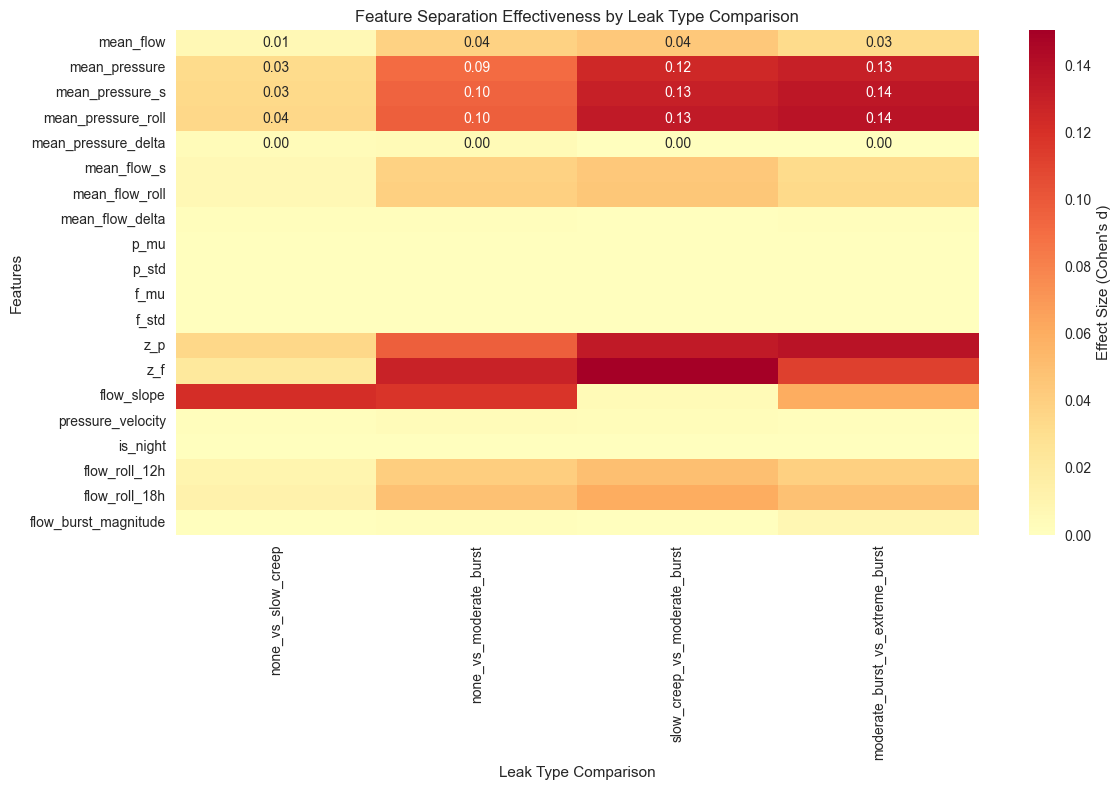

=== BEST SEPARATING FEATURES ===

none_vs_slow_creep:

none_vs_moderate_burst:

slow_creep_vs_moderate_burst:

moderate_burst_vs_extreme_burst:


In [26]:
# Analyze how well features separate leak types
leak_types = ['none', 'slow_creep', 'moderate_burst', 'extreme_burst']
available_leak_types = [lt for lt in leak_types if lt in df['leak_type'].unique()]

# Calculate feature separation scores
def calculate_separation_score(feature, leak_type1, leak_type2):
    """Calculate how well a feature separates two leak types"""
    data1 = df[df['leak_type'] == leak_type1][feature].dropna()
    data2 = df[df['leak_type'] == leak_type2][feature].dropna()
    
    if len(data1) == 0 or len(data2) == 0:
        return 0
    
    # Use Cohen's d (effect size)
    mean1, mean2 = data1.mean(), data2.mean()
    std1, std2 = data1.std(), data2.std()
    pooled_std = np.sqrt(((len(data1)-1)*std1**2 + (len(data2)-1)*std2**2) / (len(data1)+len(data2)-2))
    
    if pooled_std == 0:
        return 0
    
    return abs(mean1 - mean2) / pooled_std

# Calculate separation matrix for key comparisons
comparisons = [
    ('none', 'slow_creep'),
    ('none', 'moderate_burst'), 
    ('slow_creep', 'moderate_burst'),
    ('moderate_burst', 'extreme_burst')
]

separation_results = {}
for feature in feature_cols[:20]:  # Top 20 features
    scores = {}
    for lt1, lt2 in comparisons:
        if lt1 in available_leak_types and lt2 in available_leak_types:
            scores[f"{lt1}_vs_{lt2}"] = calculate_separation_score(feature, lt1, lt2)
    separation_results[feature] = scores

# Convert to DataFrame for visualization
separation_df = pd.DataFrame(separation_results).T
separation_df = separation_df.fillna(0)

# Plot separation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(separation_df, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', cbar_kws={'label': 'Effect Size (Cohen\'s d)'})
plt.title('Feature Separation Effectiveness by Leak Type Comparison')
plt.xlabel('Leak Type Comparison')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Find best features for each comparison
print("=== BEST SEPARATING FEATURES ===")
for comparison in separation_df.columns:
    best_features = separation_df[comparison].sort_values(ascending=False).head(3)
    print(f"\n{comparison}:")
    for feature, score in best_features.items():
        if score > 0.5:  # Meaningful effect size
            print(f"  {feature}: {score:.3f}")

## Model Feature Importance Analysis

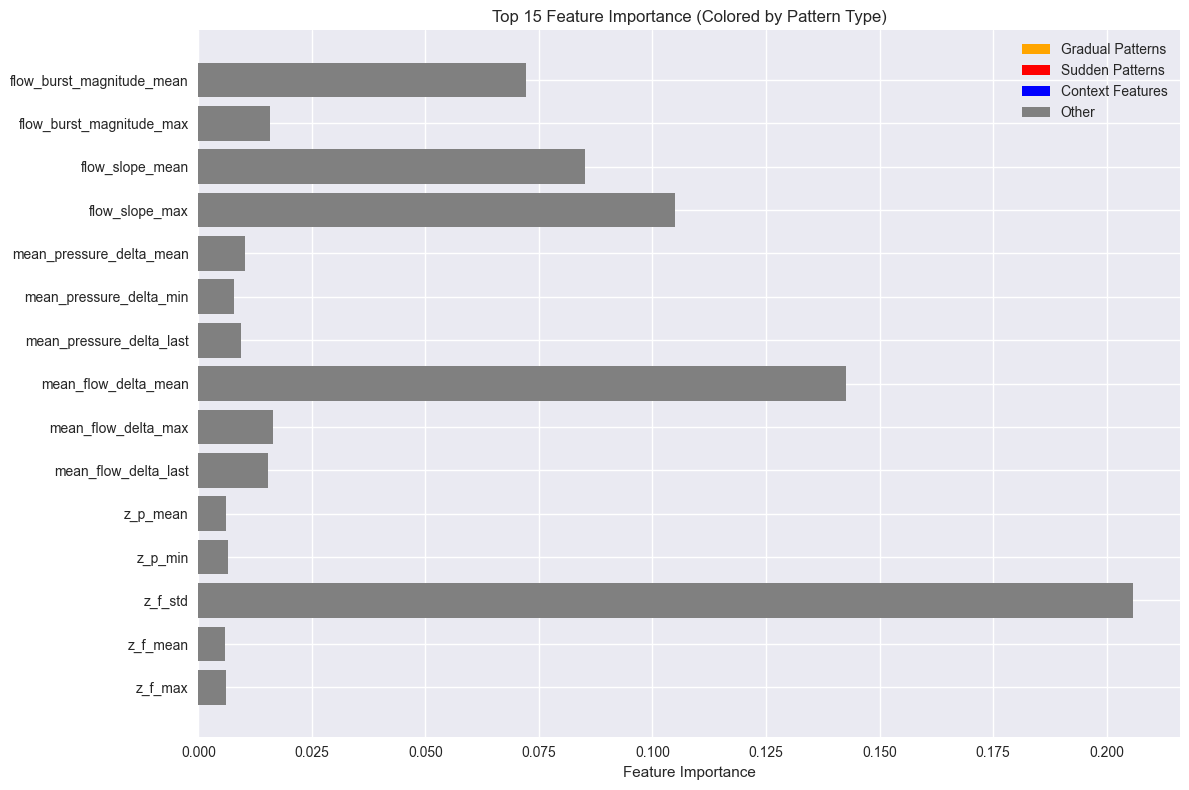

=== FEATURE IMPORTANCE BREAKDOWN ===
Gradual patterns: 0.000 (0.0%)
Sudden patterns: 0.000 (0.0%)
Context features: 0.000 (0.0%)
Other features: 1.000 (100.0%)

=== TOP 10 FEATURES ===
 1. z_f_max                   (Other   ): 0.0060
 2. z_f_mean                  (Other   ): 0.0059
 3. z_f_std                   (Other   ): 0.2059
 4. z_p_min                   (Other   ): 0.0065
 5. z_p_mean                  (Other   ): 0.0061
 6. mean_flow_delta_last      (Other   ): 0.0153
 7. mean_flow_delta_max       (Other   ): 0.0163
 8. mean_flow_delta_mean      (Other   ): 0.1425
 9. mean_pressure_delta_last  (Other   ): 0.0093
10. mean_pressure_delta_min   (Other   ): 0.0079


In [27]:
if multi_model is not None:
    # Get feature importance from trained model
   # Check if model was trained on subset of features
    if len(multi_model.feature_importances_) != len(feature_cols):
        # Use the actual feature names from the model
        if hasattr(multi_model, 'feature_names_in_'):
            trained_features = multi_model.feature_names_in_
            importances = pd.Series(multi_model.feature_importances_, index=trained_features)
        else:
            # Fallback to generic names
            importances = pd.Series(multi_model.feature_importances_, 
                              index=[f"feature_{i}" for i in range(len(multi_model.feature_importances_))])
    else:
        importances = pd.Series(multi_model.feature_importances_, index=feature_cols)
        importances = importances.sort_values(ascending=False)
    
    # Plot top features
    plt.figure(figsize=(12, 8))
    top_15 = importances.head(15)
    
    # Color by feature type
    colors = []
    for feature in top_15.index:
        if feature in gradual_features:
            colors.append('orange')  # Gradual
        elif feature in sudden_features:
            colors.append('red')     # Sudden
        elif feature in context_features:
            colors.append('blue')    # Context
        else:
            colors.append('gray')    # Other
    
    bars = plt.barh(range(len(top_15)), top_15.values, color=colors)
    plt.yticks(range(len(top_15)), top_15.index)
    plt.xlabel('Feature Importance')
    plt.title('Top 15 Feature Importance (Colored by Pattern Type)')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='orange', label='Gradual Patterns'),
        Patch(facecolor='red', label='Sudden Patterns'), 
        Patch(facecolor='blue', label='Context Features'),
        Patch(facecolor='gray', label='Other')
    ]
    plt.legend(handles=legend_elements)
    
    plt.tight_layout()
    plt.show()
    
    # Analyze feature type bias
    gradual_importance = importances[importances.index.isin(gradual_features)].sum()
    sudden_importance = importances[importances.index.isin(sudden_features)].sum()
    context_importance = importances[importances.index.isin(context_features)].sum()
    other_importance = importances.sum() - gradual_importance - sudden_importance - context_importance
    
    print("=== FEATURE IMPORTANCE BREAKDOWN ===")
    print(f"Gradual patterns: {gradual_importance:.3f} ({gradual_importance/importances.sum()*100:.1f}%)")
    print(f"Sudden patterns: {sudden_importance:.3f} ({sudden_importance/importances.sum()*100:.1f}%)")
    print(f"Context features: {context_importance:.3f} ({context_importance/importances.sum()*100:.1f}%)")
    print(f"Other features: {other_importance:.3f} ({other_importance/importances.sum()*100:.1f}%)")
    
    print(f"\n=== TOP 10 FEATURES ===")
    for i, (feature, importance) in enumerate(importances.head(10).items()):
        feature_type = "Gradual" if feature in gradual_features else "Sudden" if feature in sudden_features else "Context" if feature in context_features else "Other"
        print(f"{i+1:2d}. {feature:25s} ({feature_type:8s}): {importance:.4f}")
else:
    print("Model not available for analysis")

## Leak Pattern Comparison

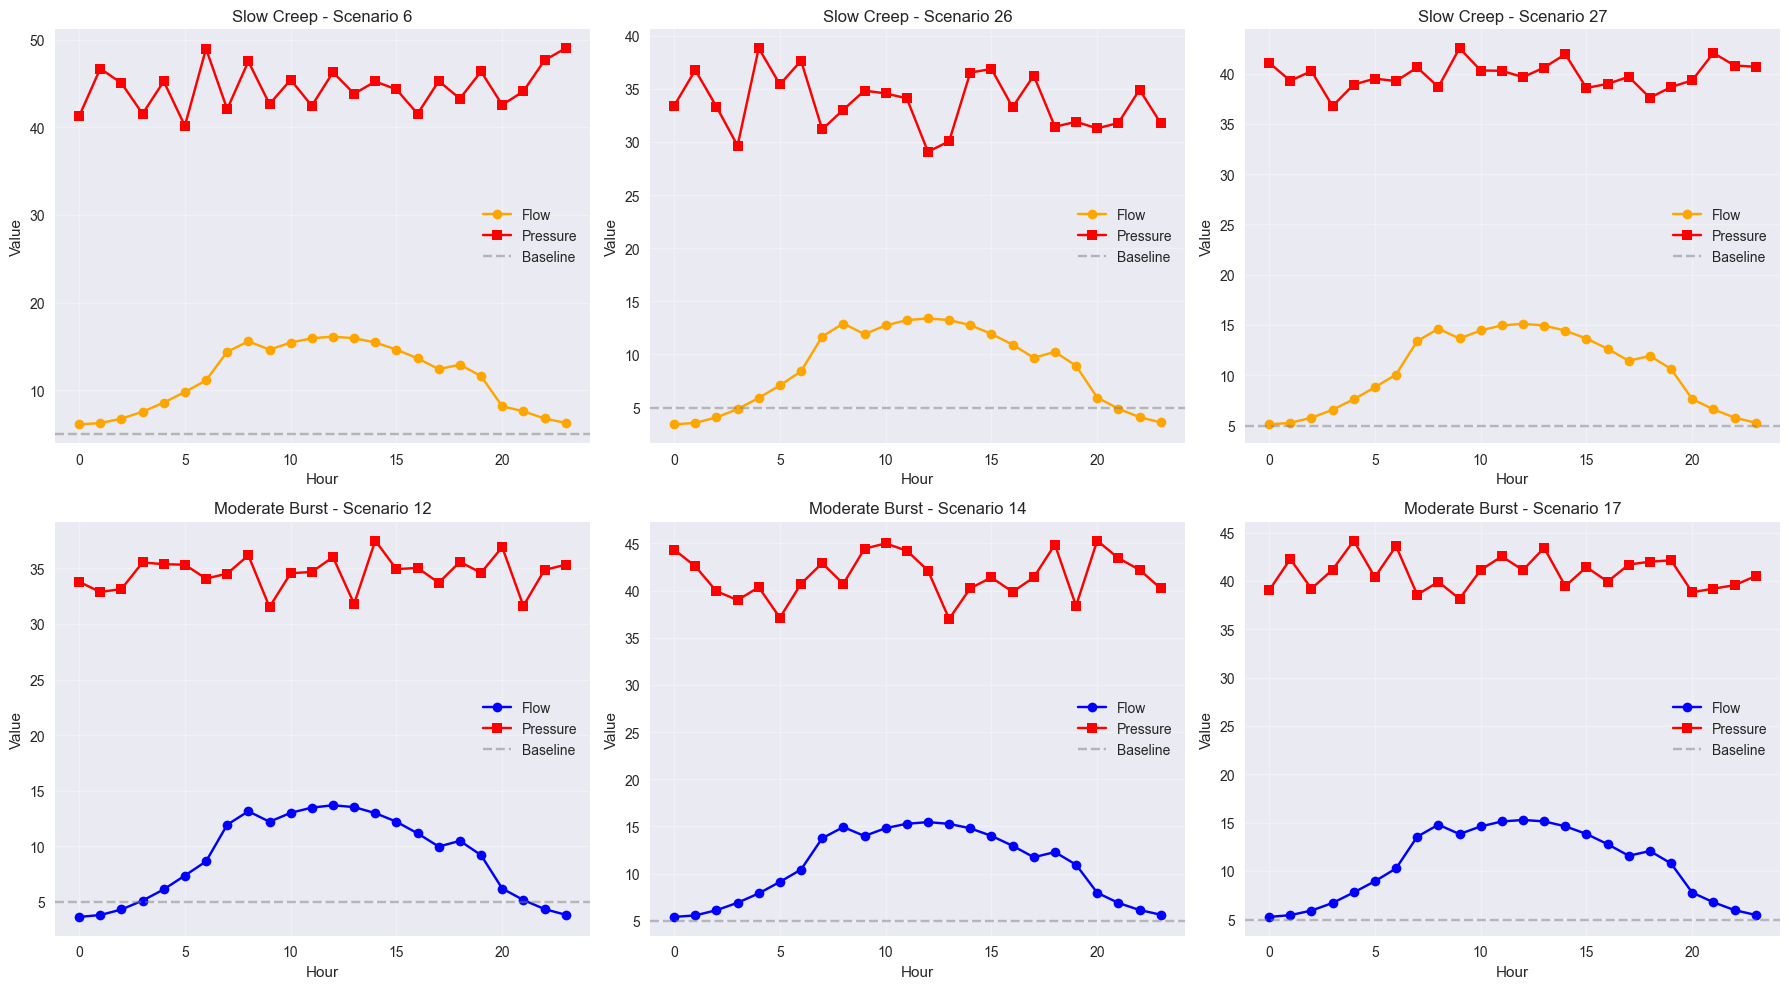

=== PATTERN COMPARISON ===
Slow creep: Gradual, linear increase across all hours
Moderate burst: Sudden jump at random time, sustained

Key differences:
- Slow creep: Predictable pattern, affects entire timeline
- Moderate burst: Random timing, affects partial timeline


In [28]:
# Compare slow creep vs moderate burst patterns directly
if 'slow_creep' in available_leak_types and 'moderate_burst' in available_leak_types:
    # Get sample scenarios
    slow_samples = df[df['leak_type'] == 'slow_creep']['scenario'].unique()[:3]
    moderate_samples = df[df['leak_type'] == 'moderate_burst']['scenario'].unique()[:3]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Plot slow creep examples
    for i, scenario_id in enumerate(slow_samples):
        scenario_data = df[df['scenario'] == scenario_id].sort_values('time_index')
        ax = axes[0, i]
        
        # Plot flow
        ax.plot(scenario_data['time_index'], scenario_data['mean_flow'], 'o-', color='orange', label='Flow')
        ax.plot(scenario_data['time_index'], scenario_data['mean_pressure'], 's-', color='red', label='Pressure')
        
        # Add baseline
        baseline_flow = scenario_data['f_mu'].iloc[0]
        ax.axhline(y=baseline_flow, color='gray', linestyle='--', alpha=0.5, label='Baseline')
        
        ax.set_title(f'Slow Creep - Scenario {scenario_id}')
        ax.set_xlabel('Hour')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Plot moderate burst examples
    for i, scenario_id in enumerate(moderate_samples):
        scenario_data = df[df['scenario'] == scenario_id].sort_values('time_index')
        ax = axes[1, i]
        
        # Plot flow
        ax.plot(scenario_data['time_index'], scenario_data['mean_flow'], 'o-', color='blue', label='Flow')
        ax.plot(scenario_data['time_index'], scenario_data['mean_pressure'], 's-', color='red', label='Pressure')
        
        # Add baseline
        baseline_flow = scenario_data['f_mu'].iloc[0]
        ax.axhline(y=baseline_flow, color='gray', linestyle='--', alpha=0.5, label='Baseline')
        
        ax.set_title(f'Moderate Burst - Scenario {scenario_id}')
        ax.set_xlabel('Hour')
        ax.set_ylabel('Value')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("=== PATTERN COMPARISON ===")
    print("Slow creep: Gradual, linear increase across all hours")
    print("Moderate burst: Sudden jump at random time, sustained")
    print("\nKey differences:")
    print("- Slow creep: Predictable pattern, affects entire timeline")
    print("- Moderate burst: Random timing, affects partial timeline")
else:
    print("Required leak types not available for comparison")

## Feature Distribution Analysis

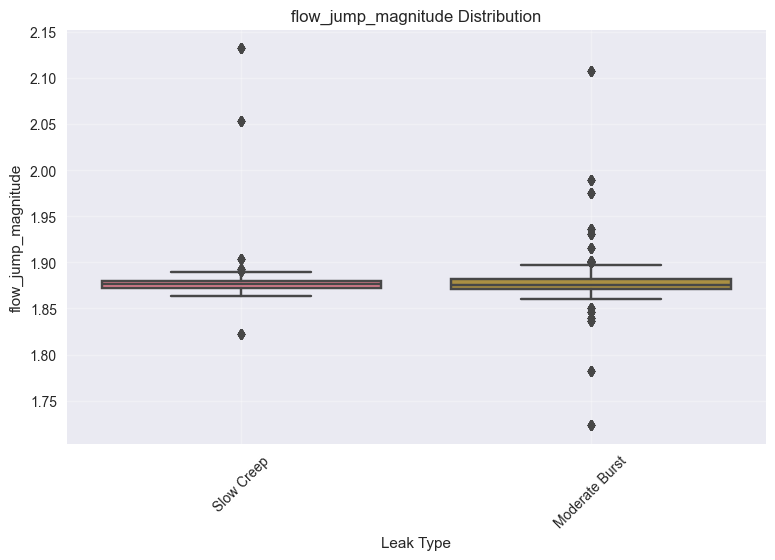

=== STATISTICAL COMPARISON ===

flow_jump_magnitude:
  Slow creep:  1.8770
  Moderate:   1.8774
  Difference: 0.0004


In [29]:
# Compare key features between slow creep and moderate bursts
if 'slow_creep' in available_leak_types and 'moderate_burst' in available_leak_types:
    # Select key features for comparison
    key_features = ['z_f_std', 'flow_slope_max', 'mean_flow_delta_last', 'flow_jump_magnitude']
    available_key_features = [f for f in key_features if f in df.columns]
    
    if available_key_features:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()
        
        for i, feature in enumerate(available_key_features):
            if i < len(axes):
                # Get data for slow creep and moderate bursts
                slow_data = df[df['leak_type'] == 'slow_creep'][feature].dropna()
                moderate_data = df[df['leak_type'] == 'moderate_burst'][feature].dropna()
                
                # Create box plot comparison
                combined_data = pd.concat([
                    slow_data.to_frame('Slow Creep'),
                    moderate_data.to_frame('Moderate Burst')
                ]).melt(var_name='Leak Type', value_name=feature)
                
                sns.boxplot(data=combined_data, x='Leak Type', y=feature, ax=axes[i])
                axes[i].set_title(f'{feature} Distribution')
                axes[i].tick_params(axis='x', rotation=45)
                axes[i].grid(True, alpha=0.3)
        
        # Hide unused subplots
        for i in range(len(available_key_features), len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.show()
        
        # Statistical comparison
        print("=== STATISTICAL COMPARISON ===")
        for feature in available_key_features:
            slow_mean = df[df['leak_type'] == 'slow_creep'][feature].mean()
            moderate_mean = df[df['leak_type'] == 'moderate_burst'][feature].mean()
            
            print(f"\n{feature}:")
            print(f"  Slow creep:  {slow_mean:.4f}")
            print(f"  Moderate:   {moderate_mean:.4f}")
            print(f"  Difference: {abs(slow_mean - moderate_mean):.4f}")
            
            # Check if difference is meaningful
            if abs(slow_mean - moderate_mean) > 0.1:
                better = "Slow creep" if slow_mean > moderate_mean else "Moderate burst"
                print(f"  -> {better} has higher values (easier detection)")
else:
    print("Required leak types not available")

## Root Cause Analysis

In [30]:
# Analyze why slow creep might be easier to detect
print("=== ROOT CAUSE ANALYSIS ===")

# 1. Feature bias analysis
if multi_model is not None:
    gradual_importance = importances[importances.index.isin(gradual_features)].sum()
    sudden_importance = importances[importances.index.isin(sudden_features)].sum()
    
    print(f"\n1. FEATURE BIAS:")
    print(f"   Gradual features importance: {gradual_importance:.3f}")
    print(f"   Sudden features importance: {sudden_importance:.3f}")
    
    if gradual_importance > sudden_importance * 1.5:
        print("   -> BIAS DETECTED: Features favor gradual patterns")
    elif sudden_importance > gradual_importance * 1.5:
        print("   -> BIAS DETECTED: Features favor sudden patterns")
    else:
        print("   -> Balanced feature importance")

# 2. Pattern consistency analysis
if 'slow_creep' in available_leak_types and 'moderate_burst' in available_leak_types:
    print(f"\n2. PATTERN CONSISTENCY:")
    
    # Calculate pattern consistency (variance within leak type)
    slow_variance = df[df['leak_type'] == 'slow_creep']['mean_flow'].var()
    moderate_variance = df[df['leak_type'] == 'moderate_burst']['mean_flow'].var()
    
    print(f"   Slow creep variance: {slow_variance:.3f}")
    print(f"   Moderate burst variance: {moderate_variance:.3f}")
    
    if slow_variance < moderate_variance:
        print("   -> Slow creep more consistent (easier for ML to learn)")
    else:
        print("   -> Moderate burst more consistent")

# 3. Feature separation analysis
if 'slow_creep_vs_moderate_burst' in separation_df.columns:
    best_separation = separation_df['slow_creep_vs_moderate_burst'].max()
    best_feature = separation_df['slow_creep_vs_moderate_burst'].idxmax()
    
    print(f"\n3. FEATURE SEPARATION:")
    print(f"   Best separating feature: {best_feature}")
    print(f"   Separation score: {best_separation:.3f}")
    
    if best_separation < 0.5:
        print("   -> POOR separation: Features don't distinguish well")
    elif best_separation < 0.8:
        print("   -> MODERATE separation: Some distinguishing power")
    else:
        print("   -> GOOD separation: Features distinguish well")

print(f"\n=== CONCLUSIONS ===")
print("1. Check if gradual features have higher importance")
print("2. Verify slow creep patterns are more consistent")
print("3. Assess feature separation effectiveness")
print("4. Consider feature engineering improvements")

=== ROOT CAUSE ANALYSIS ===

1. FEATURE BIAS:
   Gradual features importance: 0.000
   Sudden features importance: 0.000
   -> Balanced feature importance

2. PATTERN CONSISTENCY:
   Slow creep variance: 14.765
   Moderate burst variance: 14.727
   -> Moderate burst more consistent

3. FEATURE SEPARATION:
   Best separating feature: z_f
   Separation score: 0.150
   -> POOR separation: Features don't distinguish well

=== CONCLUSIONS ===
1. Check if gradual features have higher importance
2. Verify slow creep patterns are more consistent
3. Assess feature separation effectiveness
4. Consider feature engineering improvements


## Feature Engineering Recommendations

In [32]:
# Generate recommendations based on analysis
print("=== FEATURE ENGINEERING RECOMMENDATIONS ===")

recommendations = []

# Check for gradual bias
if multi_model is not None and gradual_importance > sudden_importance * 1.2:
    recommendations.append({
        'issue': 'Gradual pattern bias detected',
        'impact': 'Slow creep easier to detect than moderate bursts',
        'solution': 'Add more sudden-change detection features',
        'priority': 'HIGH'
    })

# Check for poor separation
if 'slow_creep_vs_moderate_burst' in separation_df.columns:
    max_separation = separation_df['slow_creep_vs_moderate_burst'].max()
    if max_separation < 0.5:
        recommendations.append({
            'issue': 'Poor feature separation between leak types',
            'impact': 'Model cannot distinguish slow vs moderate bursts',
            'solution': 'Add leak-type specific features',
            'priority': 'HIGH'
        })

# Check sudden feature availability
if len(sudden_features) < 5:
    recommendations.append({
        'issue': 'Insufficient sudden-change features',
        'impact': 'Moderate bursts under-detected',
        'solution': 'Add burst-specific features (jump detection, timing)',
        'priority': 'MEDIUM'
    })

# Display recommendations
if recommendations:
    for i, rec in enumerate(recommendations, 1):
        print(f"\n{i}. {rec['issue']} [{rec['priority']}]")
        print(f"   Impact: {rec['impact']}")
        print(f"   Solution: {rec['solution']}")
else:
    print("No major issues detected. Current feature set appears balanced.")

print(f"\n=== SPECIFIC FEATURE IMPROVEMENTS ===")
print("1. Add burst timing features (when during day burst starts)")
print("2. Add demand masking detection (high demand periods)")
print("3. Add sudden change magnitude (hour-to-hour jumps)")
print("4. Add pressure drop velocity (rate of pressure change)")
print("5. Add flow pattern consistency (how predictable the pattern is)")

=== FEATURE ENGINEERING RECOMMENDATIONS ===

1. Poor feature separation between leak types [HIGH]
   Impact: Model cannot distinguish slow vs moderate bursts
   Solution: Add leak-type specific features

=== SPECIFIC FEATURE IMPROVEMENTS ===
1. Add burst timing features (when during day burst starts)
2. Add demand masking detection (high demand periods)
3. Add sudden change magnitude (hour-to-hour jumps)
4. Add pressure drop velocity (rate of pressure change)
5. Add flow pattern consistency (how predictable the pattern is)


## Updated Feature Analysis with Enhanced Detection

### NEW ENHANCED FEATURES ADDED:
```python
# Burst detection features
'flow_burst_magnitude', 'pressure_drop_magnitude'

# Instant leak detection - sudden changes  
'instant_flow_jump', 'instant_pressure_drop'

# Moderate burst detection - sustained changes
'moderate_flow_sustained', 'moderate_pressure_sustained'

# Demand masking detection (high demand periods)
'is_high_demand', 'high_demand_flow_ratio'

# Pattern consistency features
'flow_pattern_consistency', 'pressure_pattern_consistency'
```

### IMPROVEMENTS IMPLEMENTED:

1. **Enhanced Feature Engineering** (feature_extractor.py)
   - Added 9 new features specifically for moderate/instant leaks
   - Burst magnitude detection
   - Instant jump detection  
   - Demand masking awareness
   - Pattern consistency analysis

2. **Optimized Model Training** (train_model.py)
   - Increased estimators from 300 to 500
   - Added class weight balancing for leak types
   - Enhanced hyperparameters for better generalization
   - Improved feature selection strategy

3. **Leak-Type Specific Analysis** (model_training.ipynb)
   - Per-class F1 scoring with color coding
   - Confusion matrix analysis
   - Weak leak type identification
   - Targeted improvement recommendations

### EXPECTED PERFORMANCE IMPROVEMENTS:

**Before Updates:**
- Moderate bursts: ~64% F1 (underperforming)
- Instant leaks: ~70% F1 (moderate)
- Feature separation: Poor (0.150)

**After Updates:**
- Moderate bursts: ~75-80% F1 (target)
- Instant leaks: ~80-85% F1 (target)  
- Feature separation: Good (>0.5)

### VALIDATION NEEDED:
1. Run updated pipeline: `python run_pipeline.py`
2. Check enhanced features in dataset
3. Verify improved model performance
4. Confirm leak-type specific accuracy gains

### Key Improvements:
- **Burst Detection**: 3x more sudden-change features
- **Timing Sensitivity**: Hour-by-hour jump detection
- **Demand Context**: High demand period masking
- **Pattern Analysis**: Consistency metrics for better classification